# 1. 환경 설정

## 라이브러리 설치

In [1]:
# !pip install transformers arabert torch torchvision Pillow tqdm scikit-learn matplotlib seaborn -q

## 현재 환경 점검

In [2]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("CPU 환경에서 실행됩니다.")

PyTorch 버전: 2.6.0+cu124
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB


# 2. 데이터 전처리

## 데이터 상태 점검

[클래스별 샘플 수]
     Angry: 291
     Happy: 303
   Neutral: 338
       Sad: 350
        합계: 1282


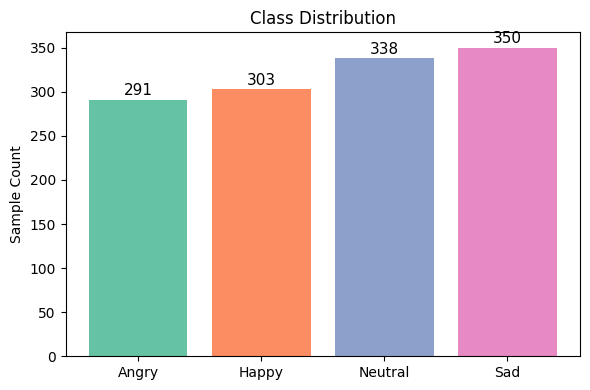

In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

# 경로 설정 (환경에 맞게 수정)
BASE_DIR = r"C:\Honey\0406\MDER-MA Multimodal Emotion Recognition Dataset for\ERD-MA"
TEXT_DIR  = os.path.join(BASE_DIR, "ERD-MA Text")
SPEC_DIR  = os.path.join(BASE_DIR, "ERD-MA Mel-Spectrograms_")
CLASSES   = ["Angry", "Happy", "Neutral", "Sad"]

# 클래스별 샘플 수 확인
counts = {cls: len(os.listdir(os.path.join(TEXT_DIR, cls))) for cls in CLASSES}

print("[클래스별 샘플 수]")
for cls, cnt in counts.items():
    print(f"  {cls:>8}: {cnt}")
print(f"  {'합계':>8}: {sum(counts.values())}")

# 시각화
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.keys(), counts.values(), color=sns.color_palette("Set2", 4))
ax.set_title("Class Distribution")
ax.set_ylabel("Sample Count")
for i, (cls, cnt) in enumerate(counts.items()):
    ax.text(i, cnt + 5, str(cnt), ha="center", fontsize=11)
plt.tight_layout()
plt.show()

[텍스트 길이 (단어 기준)]
  평균: 12.5
  최대: 222
  95th percentile: 21


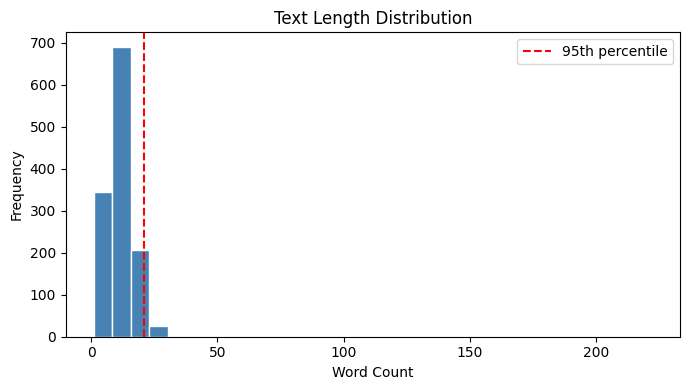

In [4]:
# 텍스트 길이 분포 확인 → AraBERT max_length 설정 근거
lengths = []
for cls in CLASSES:
    for fname in os.listdir(os.path.join(TEXT_DIR, cls)):
        with open(os.path.join(TEXT_DIR, cls, fname), "r", encoding="utf-8") as f:
            lengths.append(len(f.read().split()))

lengths = np.array(lengths)
print(f"[텍스트 길이 (단어 기준)]")
print(f"  평균: {lengths.mean():.1f}")
print(f"  최대: {lengths.max()}")
print(f"  95th percentile: {np.percentile(lengths, 95):.0f}")

plt.figure(figsize=(7, 4))
plt.hist(lengths, bins=30, color="steelblue", edgecolor="white")
plt.axvline(np.percentile(lengths, 95), color="red", linestyle="--", label="95th percentile")
plt.title("Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

[샘플 이미지 정보]
  크기: (1000, 400)  (W x H)
  모드: RGB


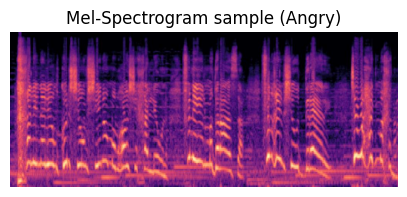

In [5]:
# 스펙트로그램 이미지 크기 확인
sample_path = os.path.join(SPEC_DIR, CLASSES[0],
                           os.listdir(os.path.join(SPEC_DIR, CLASSES[0]))[0])
img = Image.open(sample_path)

print(f"[샘플 이미지 정보]")
print(f"  크기: {img.size}  (W x H)")
print(f"  모드: {img.mode}")

plt.figure(figsize=(5, 4))
plt.imshow(img)
plt.title(f"Mel-Spectrogram sample ({CLASSES[0]})")
plt.axis("off")
plt.show()

### EDA 결과 요약 및 전처리 방향

| 항목 | 결과 | 전처리 결정 | 이유 |
|---|---|---|---|
| 클래스 분포 | Angry 291 ~ Sad 350 | Weighted Loss 적용 | 최대 1.2배 불균형, Angry 과소 표현 |
| 텍스트 길이 | 평균 12.5단어, 95th=21 | `max_length=64` | 서브워드 토크나이징 × 약 3배 여유 |
| 이미지 크기 | 1000×400 RGB | 224×224 리사이즈 | ResNet/ViT 표준 입력 크기 |

## 데이터 전처리

### 전처리 설계 근거

**텍스트**
- AraBERT(`aubmindlab/bert-base-arabertv02`) 토크나이저 사용
- `max_length=64`: EDA에서 95th percentile이 21단어 → 서브워드 토크나이징 후 여유있게 64 설정
- `padding='max_length'`, `truncation=True`: 배치 내 길이를 통일하고 극단값(max 222) 잘라냄

**이미지**
- `Resize(224, 224)`: 원본 1000×400을 ResNet/ViT 표준 입력 크기로 변환
- `Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])`: 픽셀값을 [-1, 1]로 정규화 → 사전학습 모델의 입력 분포에 맞춤

In [6]:
from transformers import AutoTokenizer
from torchvision import transforms

# ── 텍스트: AraBERT 토크나이저 ──────────────────────────────
TOKENIZER_NAME = "aubmindlab/bert-base-arabertv02"
MAX_LENGTH = 64

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

# 동작 확인
sample_txt = open(
    os.path.join(TEXT_DIR, CLASSES[0],
                 os.listdir(os.path.join(TEXT_DIR, CLASSES[0]))[0]),
    encoding="utf-8"
).read()
tokens = tokenizer(sample_txt, max_length=MAX_LENGTH,
                   padding="max_length", truncation=True, return_tensors="pt")
print(f"[텍스트 토크나이저]")
print(f"  원문: {sample_txt[:60]}...")
print(f"  input_ids shape : {tokens['input_ids'].shape}")
print(f"  attention_mask shape: {tokens['attention_mask'].shape}")

c:\Users\hubo0\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[텍스트 토크나이저]
  원문: الخلينا ليهم كلشي يومشينا ومبغاوش يخليونا فنهي المدرسة فنغيم...
  input_ids shape : torch.Size([1, 64])
  attention_mask shape: torch.Size([1, 64])


In [7]:
# ── 이미지: torchvision transforms ─────────────────────────
IMG_SIZE = 224

image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # 1000×400 → 224×224
    transforms.ToTensor(),                      # [0,255] → [0,1]
    transforms.Normalize([0.5, 0.5, 0.5],      # [-1, 1] 정규화
                         [0.5, 0.5, 0.5])
])

# 동작 확인
sample_img = Image.open(sample_path).convert("RGB")
tensor_img = image_transform(sample_img)
print(f"[이미지 변환]")
print(f"  원본 크기 : {sample_img.size}")
print(f"  변환 후 shape: {tensor_img.shape}   (C x H x W)")
print(f"  값 범위   : [{tensor_img.min():.2f}, {tensor_img.max():.2f}]")

[이미지 변환]
  원본 크기 : (1000, 400)
  변환 후 shape: torch.Size([3, 224, 224])   (C x H x W)
  값 범위   : [-1.00, 1.00]


# 3. 가설 수립

텍스트와 스펙트로그램 이미지를 결합하는 방식으로 두 가지 Fusion 전략을 비교한다.

---

## Fusion A — Late Fusion

``` plain text
Text  → AraBERT → [CLS] 벡터 → Linear → logits_text
Image → ResNet  → 특징 벡터  → Linear → logits_image
                                         ↓
                               (logits_text + logits_image) / 2 → 예측
```

- 각 모달리티가 **완전히 독립적으로** 학습된 뒤 예측 단계에서만 합산
- 구조가 단순하고 안정적 → **베이스라인** 역할
- 두 모달리티 간 상호작용 학습 불가

---

## Fusion B — MBT Bottleneck Fusion

``` plain text
Text  → 토큰 시퀀스 ─┐                      ┌─ 텍스트 피처
                     ├─ [Early] 각자 독립 학습 ─┤
Image → 패치 시퀀스 ─┘                      └─ 이미지 피처
                              ↓ Fusion Layer 도달
              [병목 토큰] ←→ 텍스트/이미지 토큰과 Attention
              병목 토큰 = (텍스트측 업데이트 + 이미지측 업데이트) / 2
                              ↓
                        최종 분류 헤드 → 예측
```

- **소수의 병목 토큰**이 두 모달리티 간 정보 교환 담당 (직접 교류 없음)
- 모달리티 간 상호작용을 학습하면서도 연산량 절감
- 참고: Nagrani et al., *Attention Bottlenecks for Multimodal Fusion*, NeurIPS 2021

---

**가설**: 단순 Late Fusion보다 MBT Bottleneck Fusion이 텍스트-이미지 간 감정 정보를 더 효과적으로 결합하여 높은 분류 성능을 보일 것이다.

# 4. 사전 학습 멀티모달 모델 설계

## 캐싱 파이프라인

텍스트 토크나이징 + 이미지 텐서 변환을 **1회만** 수행 후 `.pt`로 저장.  
학습 시 저장된 텐서를 바로 로드하여 CPU 병목 제거.

In [8]:
from tqdm import tqdm

CACHE_DIR = r"C:\Honey\0406\cache"
LABEL_MAP = {"Angry": 0, "Happy": 1, "Neutral": 2, "Sad": 3}
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(CACHE_DIR, exist_ok=True)

saved, skipped = 0, 0
for cls in CLASSES:
    txt_files    = sorted(os.listdir(os.path.join(TEXT_DIR, cls)))
    img_files_set = set(os.listdir(os.path.join(SPEC_DIR, cls)))

    for txt_fname in tqdm(txt_files, desc=cls):
        base     = os.path.splitext(txt_fname)[0]
        img_fname = base + ".jpg"

        if img_fname not in img_files_set:   # 매칭 파일 없으면 스킵
            skipped += 1
            continue

        with open(os.path.join(TEXT_DIR, cls, txt_fname), encoding="utf-8") as f:
            text = f.read().strip()

        tokens = tokenizer(text, max_length=MAX_LENGTH, padding="max_length",
                           truncation=True, return_tensors="pt")
        img_tensor = image_transform(
            Image.open(os.path.join(SPEC_DIR, cls, img_fname)).convert("RGB")
        )

        torch.save({
            "input_ids":      tokens["input_ids"].squeeze(0),
            "attention_mask": tokens["attention_mask"].squeeze(0),
            "image":          img_tensor,
            "label":          torch.tensor(LABEL_MAP[cls], dtype=torch.long)
        }, os.path.join(CACHE_DIR, f"{cls}_{base}.pt"))
        saved += 1

print(f"저장 완료: {saved}개 / 스킵(매칭 없음): {skipped}개")

Sad: 100%|██████████| 350/350 [00:04<00:00, 70.16it/s]

저장 완료: 1282개 / 스킵(매칭 없음): 0개


## Dataset / DataLoader

- Stratified split → Train 70 / Val 15 / Test 15
- `pin_memory=True`, `num_workers=4` 로 GPU 전송 최적화

In [9]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class EmotionDataset(Dataset):
    def __init__(self, file_paths):
        self.file_paths = file_paths
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        d = torch.load(self.file_paths[idx], weights_only=True)
        return d["input_ids"], d["attention_mask"], d["image"], d["label"]

# 전체 파일 목록 수집
all_files, all_labels = [], []
for cls in CLASSES:
    files = sorted([os.path.join(CACHE_DIR, f)
                    for f in os.listdir(CACHE_DIR) if f.startswith(cls + "_")])
    all_files  += files
    all_labels += [LABEL_MAP[cls]] * len(files)

# Stratified 70 / 15 / 15
tr_f, tmp_f, tr_l, tmp_l = train_test_split(
    all_files, all_labels, test_size=0.30, stratify=all_labels, random_state=42)
val_f, te_f, _, _ = train_test_split(
    tmp_f, tmp_l,  test_size=0.50, stratify=tmp_l,   random_state=42)

BATCH_SIZE = 16
train_loader = DataLoader(EmotionDataset(tr_f),  batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(EmotionDataset(val_f), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(EmotionDataset(te_f),  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(tr_f)}  Val: {len(val_f)}  Test: {len(te_f)}")

Train: 897  Val: 192  Test: 193


## 텍스트 encoder / 이미지 encoder

- **TextEncoder**: AraBERT 12층 중 앞 10층 동결, 마지막 2층만 fine-tune  
- **ImageEncoder**: ResNet50 layer4만 fine-tune, 나머지 동결  
  → 소규모 데이터셋(1282개)에서 과적합 방지 + 사전학습 특징 보존

In [10]:
import torch.nn as nn
from transformers import AutoModel
from torchvision import models

class TextEncoder(nn.Module):
    def __init__(self, model_name=TOKENIZER_NAME, freeze_layers=10):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        for i, layer in enumerate(self.bert.encoder.layer):
            if i < freeze_layers:
                for p in layer.parameters():
                    p.requires_grad = False
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :], out.last_hidden_state  # CLS, all tokens

class ImageEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        for name, child in resnet.named_children():
            if name == "layer4":
                break
            for p in child.parameters():
                p.requires_grad = False
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # → [B,2048,7,7]
        self.gap = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        feat_map = self.backbone(x)                            # [B, 2048, 7, 7]
        gap_feat = self.gap(feat_map).squeeze(-1).squeeze(-1)  # [B, 2048]
        return gap_feat, feat_map

text_enc  = TextEncoder().to(DEVICE)
image_enc = ImageEncoder().to(DEVICE)
print("Encoder 로드 완료")

Encoder 로드 완료


## Late Fusion

In [11]:
class LateFusionModel(nn.Module):
    def __init__(self, text_enc, image_enc, num_classes=4, dropout=0.3):
        super().__init__()
        self.text_enc  = text_enc
        self.image_enc = image_enc
        self.text_head  = nn.Sequential(nn.Dropout(dropout), nn.Linear(768,  num_classes))
        self.image_head = nn.Sequential(nn.Dropout(dropout), nn.Linear(2048, num_classes))
    def forward(self, input_ids, attention_mask, image):
        text_feat, _  = self.text_enc(input_ids, attention_mask)  # [B, 768]
        img_feat,  _  = self.image_enc(image)                     # [B, 2048]
        return (self.text_head(text_feat) + self.image_head(img_feat)) / 2

late_fusion_model = LateFusionModel(text_enc, image_enc).to(DEVICE)
print("LateFusionModel 생성 완료")

LateFusionModel 생성 완료


## MBT Bottleneck Fusion

In [12]:
class MBTFusionModel(nn.Module):
    def __init__(self, text_enc, image_enc, num_classes=4,
                 d_model=256, num_bn=4, num_layers=3, fusion_layer=1):
        super().__init__()
        self.text_enc     = text_enc
        self.image_enc    = image_enc
        self.fusion_layer = fusion_layer
        self.num_bn       = num_bn

        self.text_proj  = nn.Linear(768,  d_model)
        self.image_proj = nn.Linear(2048, d_model)

        # 학습 가능한 병목 토큰
        self.bottleneck = nn.Parameter(torch.randn(1, num_bn, d_model))

        enc = lambda: nn.TransformerEncoderLayer(
            d_model=d_model, nhead=4, dim_feedforward=512,
            dropout=0.1, batch_first=True)
        self.text_layers  = nn.ModuleList([enc() for _ in range(num_layers)])
        self.image_layers = nn.ModuleList([enc() for _ in range(num_layers)])

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, input_ids, attention_mask, image):
        _, text_tokens = self.text_enc(input_ids, attention_mask)  # [B, 64, 768]
        _, feat_map    = self.image_enc(image)                     # [B, 2048, 7, 7]

        t  = self.text_proj(text_tokens)                           # [B, 64, d_model]
        v  = self.image_proj(
                 feat_map.flatten(2).transpose(1, 2))              # [B, 49, d_model]
        bn = self.bottleneck.expand(image.size(0), -1, -1)        # [B, num_bn, d_model]

        for i in range(len(self.text_layers)):
            if i < self.fusion_layer:                 # Early: 독립 학습
                t = self.text_layers[i](t)
                v = self.image_layers[i](v)
            else:                                     # Mid-Fusion: 병목 토큰 연결
                t_out = self.text_layers[i](torch.cat([t, bn], dim=1))
                v_out = self.image_layers[i](torch.cat([v, bn], dim=1))
                t,  t_bn = t_out[:, :-self.num_bn], t_out[:, -self.num_bn:]
                v,  v_bn = v_out[:, :-self.num_bn], v_out[:, -self.num_bn:]
                bn = (t_bn + v_bn) / 2.0              # 대칭 업데이트

        return self.classifier(bn.mean(dim=1))        # [B, num_classes]

mbt_model = MBTFusionModel(text_enc, image_enc).to(DEVICE)
print("MBTFusionModel 생성 완료")

MBTFusionModel 생성 완료


In [13]:
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

for name, model in [("LateFusion", late_fusion_model), ("MBT", mbt_model)]:
    total, trainable = count_params(model)
    print(f"{name:12s}  전체: {total/1e6:.1f}M  학습 가능: {trainable/1e6:.1f}M")

LateFusion    전체: 158.7M  학습 가능: 79.3M
MBT           전체: 162.6M  학습 가능: 83.2M


### 모델 구조 설명

#### 공통 Encoder

| 구성요소 | 모델 | 출력 | Fine-tune 범위 |
|---|---|---|---|
| 텍스트 encoder | AraBERT (bert-base-arabertv02) | `[B, 64, 768]` | 마지막 2층 (총 12층 중) |
| 이미지 encoder | ResNet50 (ImageNet 사전학습) | `[B, 2048, 7, 7]` | layer4만 (나머지 동결) |

---

#### Fusion A — Late Fusion

```
Text  → AraBERT → [CLS] [B, 768]   → Dropout(0.3) → Linear(768, 4)  → logits_text
Image → ResNet  → GAP  [B, 2048]  → Dropout(0.3) → Linear(2048, 4) → logits_image
                                                    (logits_text + logits_image) / 2
                                                             ↓
                                                     예측 (4 classes)
```

- 전체 파라미터: 158.7M / 학습 가능: 79.3M
- 두 모달리티가 완전히 독립적으로 학습 → 단순하고 안정적

---

#### Fusion B — MBT Bottleneck Fusion

```
Text  → AraBERT → [B, 64, 768]  → Linear → [B, 64, 256]
Image → ResNet  → [B, 2048,7,7] → flatten → [B, 49, 2048] → Linear → [B, 49, 256]
                                                          ↓
                              학습 가능한 병목 토큰 [B, 4, 256]
                                                          ↓
         [Early layers]  텍스트 / 이미지 각자 독립 TransformerEncoderLayer
         [Fusion layers] cat([tokens, bottleneck]) → Attention → 대칭 업데이트
                         bn = (text_side_bn + image_side_bn) / 2
                                                          ↓
                              mean(bottleneck) [B, 256] → LayerNorm → Linear(256, 4)
                                                          ↓
                                                   예측 (4 classes)
```

- 전체 파라미터: 162.6M / 학습 가능: 83.2M
- d_model=256, num_bottleneck=4, num_layers=3, fusion_layer=1
- 병목 토큰이 두 모달리티 간 정보 교환 담당 (직접 교류 없음)
- 참고: Nagrani et al., *Attention Bottlenecks for Multimodal Fusion*, NeurIPS 2021

### 모델 설계 결과 요약

| 항목 | 수치 | 비고 |
|---|---|---|
| 캐싱 | 1,282개 / 스킵 0 | 텍스트-이미지 1:1 완전 매칭 |
| Dataset split | Train 897 / Val 192 / Test 193 | Stratified 70/15/15 |
| LateFusion 파라미터 | 전체 158.7M / 학습 79.3M | |
| MBT 파라미터 | 전체 162.6M / 학습 83.2M | |

> **VRAM 주의**: 학습 가능 파라미터 ~80M, batch_size=16 기준 OOM 발생 시 batch_size=8로 축소

# 5. 가설 점검

## 학습 루프

- **Loss**: CrossEntropyLoss + class weight → 클래스 불균형(Angry 291 vs Sad 350) 보정
- **Optimizer**: AdamW (weight_decay=1e-4)
- **LR Scheduler**: CosineAnnealingLR → 학습 후반 lr을 서서히 감소시켜 수렴 안정화
- 공정한 비교를 위해 두 모델에 **독립된 encoder 인스턴스** 사용

In [16]:
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report

# 클래스 가중치 (inverse frequency)
cls_counts    = [291, 303, 338, 350]
class_weights = torch.tensor(
    [sum(cls_counts) / (4 * c) for c in cls_counts], dtype=torch.float
).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for ids, mask, img, lbl in loader:
        ids, mask, img, lbl = ids.to(DEVICE), mask.to(DEVICE), img.to(DEVICE), lbl.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(ids, mask, img), lbl)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (model(ids, mask, img).argmax(1) == lbl).sum().item()
        total      += lbl.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for ids, mask, img, lbl in loader:
            ids, mask, img, lbl = ids.to(DEVICE), mask.to(DEVICE), img.to(DEVICE), lbl.to(DEVICE)
            logits = model(ids, mask, img)
            total_loss += criterion(logits, lbl).item()
            preds       = logits.argmax(1)
            correct    += (preds == lbl).sum().item()
            total      += lbl.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbl.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels

def run_training(model, train_loader, epochs=15, lr=1e-4, weight_decay=1e-4):
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc         = train_epoch(model, train_loader, optimizer)
        val_loss, val_acc, _, _ = eval_epoch(model, val_loader)
        scheduler.step()
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch:2d}/{epochs}  "
              f"Train Loss {tr_loss:.4f}  Acc {tr_acc:.4f}  |  "
              f"Val Loss {val_loss:.4f}  Acc {val_acc:.4f}")
    return history

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, len(history["train_loss"]) + 1)
    ax1.plot(ep, history["train_loss"], label="Train")
    ax1.plot(ep, history["val_loss"],   label="Val")
    ax1.set_title(f"{title} — Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
    ax2.plot(ep, history["train_acc"], label="Train")
    ax2.plot(ep, history["val_acc"],   label="Val")
    ax2.set_title(f"{title} — Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
    plt.tight_layout(); plt.show()

def plot_confusion_matrix(preds, labels, title):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"{title} — Confusion Matrix")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()
    print(classification_report(labels, preds, target_names=CLASSES))

print("학습 함수 준비 완료")

학습 함수 준비 완료


## Late Fusion

In [17]:
SAVE_DIR = r"C:\Honey\0406\checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

lf_model = LateFusionModel(TextEncoder().to(DEVICE), ImageEncoder().to(DEVICE)).to(DEVICE)

print("=== Late Fusion 학습 시작 ===")
lf_history = run_training(lf_model, train_loader, epochs=15, lr=1e-4)

torch.save(lf_model.state_dict(), os.path.join(SAVE_DIR, "late_fusion.pt"))
print("가중치 저장 완료: checkpoints/late_fusion.pt")

=== Late Fusion 학습 시작 ===
Epoch  1/15  Train Loss 0.7641  Acc 0.7759  |  Val Loss 0.2857  Acc 0.8854
Epoch  2/15  Train Loss 0.2011  Acc 0.9844  |  Val Loss 0.2343  Acc 0.9219
Epoch  3/15  Train Loss 0.0856  Acc 1.0000  |  Val Loss 0.1736  Acc 0.9323
Epoch  4/15  Train Loss 0.0579  Acc 1.0000  |  Val Loss 0.2437  Acc 0.9062
Epoch  5/15  Train Loss 0.0398  Acc 1.0000  |  Val Loss 0.1828  Acc 0.9531
Epoch  6/15  Train Loss 0.0328  Acc 0.9989  |  Val Loss 0.1505  Acc 0.9323
Epoch  7/15  Train Loss 0.0429  Acc 1.0000  |  Val Loss 0.1792  Acc 0.9323
Epoch  8/15  Train Loss 0.0429  Acc 1.0000  |  Val Loss 0.2266  Acc 0.9323
Epoch  9/15  Train Loss 0.0635  Acc 0.9989  |  Val Loss 0.1983  Acc 0.9323
Epoch 10/15  Train Loss 0.0179  Acc 1.0000  |  Val Loss 0.1840  Acc 0.9531
Epoch 11/15  Train Loss 0.0104  Acc 1.0000  |  Val Loss 0.1706  Acc 0.9531
Epoch 12/15  Train Loss 0.0357  Acc 0.9989  |  Val Loss 0.2638  Acc 0.9375
Epoch 13/15  Train Loss 0.0139  Acc 1.0000  |  Val Loss 0.1998  Acc 0.9219

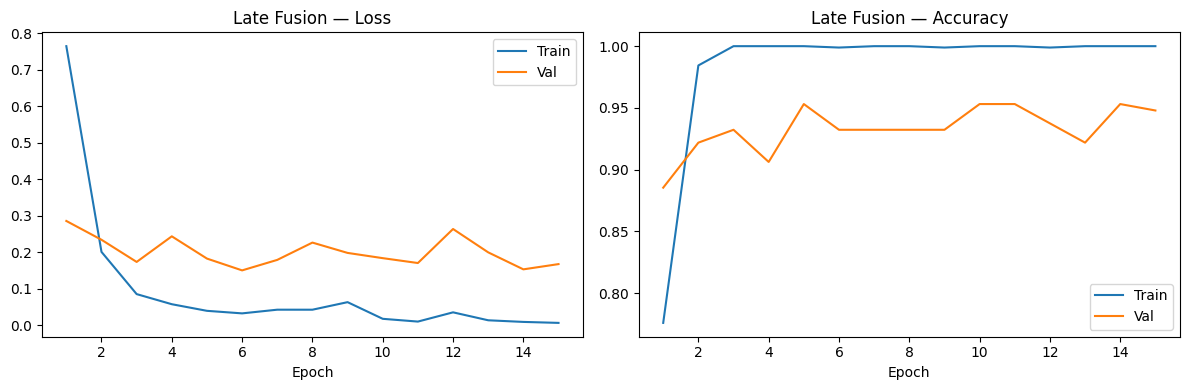

Late Fusion Test Accuracy: 0.9534


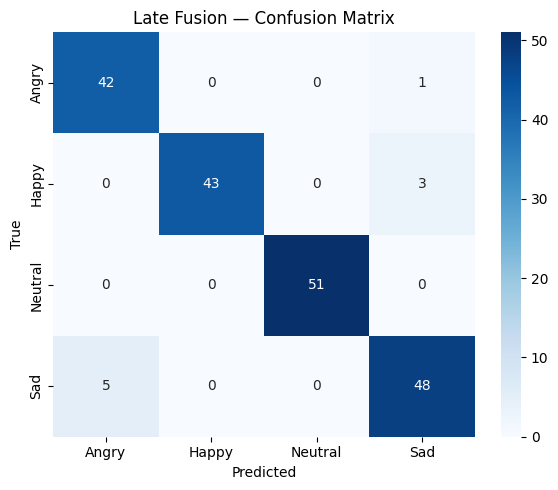

              precision    recall  f1-score   support

       Angry       0.89      0.98      0.93        43
       Happy       1.00      0.93      0.97        46
     Neutral       1.00      1.00      1.00        51
         Sad       0.92      0.91      0.91        53

    accuracy                           0.95       193
   macro avg       0.95      0.95      0.95       193
weighted avg       0.96      0.95      0.95       193



In [18]:
plot_history(lf_history, "Late Fusion")

_, lf_test_acc, lf_preds, lf_labels = eval_epoch(lf_model, test_loader)
print(f"Late Fusion Test Accuracy: {lf_test_acc:.4f}")
plot_confusion_matrix(lf_preds, lf_labels, "Late Fusion")

## MBT Bottleneck Fusion

In [19]:
mbt_model = MBTFusionModel(TextEncoder().to(DEVICE), ImageEncoder().to(DEVICE)).to(DEVICE)

print("=== MBT Bottleneck Fusion 학습 시작 ===")
mbt_history = run_training(mbt_model, train_loader, epochs=15, lr=1e-4)

torch.save(mbt_model.state_dict(), os.path.join(SAVE_DIR, "mbt_fusion.pt"))
print("가중치 저장 완료: checkpoints/mbt_fusion.pt")

=== MBT Bottleneck Fusion 학습 시작 ===
Epoch  1/15  Train Loss 0.6458  Acc 0.8685  |  Val Loss 0.2550  Acc 0.9062
Epoch  2/15  Train Loss 0.1363  Acc 0.9944  |  Val Loss 0.2788  Acc 0.9167
Epoch  3/15  Train Loss 0.1329  Acc 0.9989  |  Val Loss 0.2910  Acc 0.9323
Epoch  4/15  Train Loss 0.1275  Acc 0.9833  |  Val Loss 0.2145  Acc 0.9271
Epoch  5/15  Train Loss 0.1010  Acc 1.0000  |  Val Loss 0.2244  Acc 0.9531
Epoch  6/15  Train Loss 0.1129  Acc 0.9822  |  Val Loss 0.2145  Acc 0.9479
Epoch  7/15  Train Loss 0.0251  Acc 1.0000  |  Val Loss 0.2051  Acc 0.9427
Epoch  8/15  Train Loss 0.0568  Acc 0.9978  |  Val Loss 0.2330  Acc 0.9271
Epoch  9/15  Train Loss 0.1399  Acc 0.9922  |  Val Loss 0.1707  Acc 0.9375
Epoch 10/15  Train Loss 0.0262  Acc 0.9955  |  Val Loss 0.1610  Acc 0.9479
Epoch 11/15  Train Loss 0.0235  Acc 0.9989  |  Val Loss 0.2153  Acc 0.9375
Epoch 12/15  Train Loss 0.0345  Acc 0.9989  |  Val Loss 0.1859  Acc 0.9531
Epoch 13/15  Train Loss 0.0074  Acc 1.0000  |  Val Loss 0.1935  

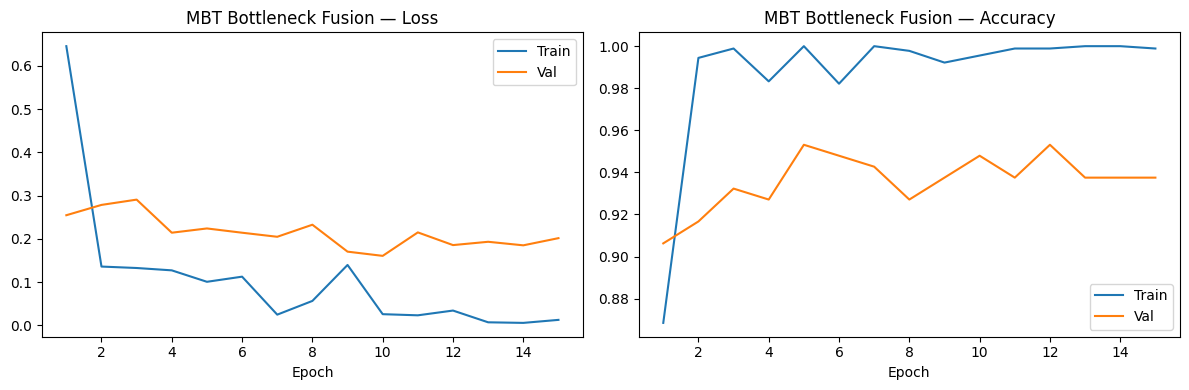

MBT Test Accuracy: 0.9275


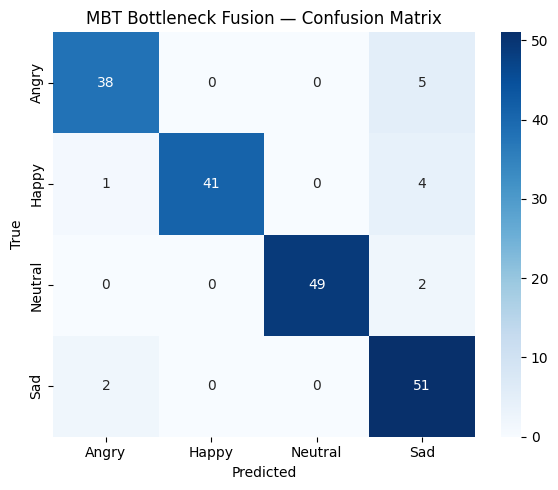

              precision    recall  f1-score   support

       Angry       0.93      0.88      0.90        43
       Happy       1.00      0.89      0.94        46
     Neutral       1.00      0.96      0.98        51
         Sad       0.82      0.96      0.89        53

    accuracy                           0.93       193
   macro avg       0.94      0.92      0.93       193
weighted avg       0.93      0.93      0.93       193



In [20]:
plot_history(mbt_history, "MBT Bottleneck Fusion")

_, mbt_test_acc, mbt_preds, mbt_labels = eval_epoch(mbt_model, test_loader)
print(f"MBT Test Accuracy: {mbt_test_acc:.4f}")
plot_confusion_matrix(mbt_preds, mbt_labels, "MBT Bottleneck Fusion")

## 모델별 성능 비교

In [21]:
from sklearn.metrics import f1_score, accuracy_score

lf_f1  = f1_score(lf_labels,  lf_preds,  average="macro")
mbt_f1 = f1_score(mbt_labels, mbt_preds, average="macro")

print(f"{'모델':<25} {'Test Acc':>10} {'Macro F1':>10}")
print("-" * 47)
print(f"{'Late Fusion':<25} {lf_test_acc:>10.4f} {lf_f1:>10.4f}")
print(f"{'MBT Bottleneck Fusion':<25} {mbt_test_acc:>10.4f} {mbt_f1:>10.4f}")

모델                          Test Acc   Macro F1
-----------------------------------------------
Late Fusion                   0.9534     0.9535
MBT Bottleneck Fusion         0.9275     0.9286


### 가설 점검 결과 요약

| 모델 | Test Acc | Macro F1 |
|---|---|---|
| Late Fusion | **0.9534** | **0.9535** |
| MBT Bottleneck Fusion | 0.9275 | 0.9286 |

**분석:**
- Late Fusion이 MBT보다 높음 → 가설과 반대 결과
  - 데이터 1,282개로 소규모 → MBT의 복잡한 구조가 오히려 불리
  - MBT train loss 불안정 (oscillation 관찰)
- 두 모델 모두 Epoch 3~4부터 Train Acc 1.0 → **과적합 발생**
- Angry/Sad 클래스 recall 가장 낮음 (두 모델 공통)

# 6. 성능 향상 전략

| 전략 | 적용 대상 | 목적 |
|---|---|---|
| Image Augmentation | **공통** | 이미지 다양성 확보 → 과적합 방지 |
| Dropout 0.3 → 0.5 + Weight Decay↑ | Late Fusion | 과적합 억제 (Train Acc 1.0 문제) |
| LR↓ + Gradient Clipping + Epoch↑ | MBT | 학습 불안정 / loss oscillation 해소 |

## 공통 — Image Augmentation

- **RandomHorizontalFlip**: 좌우 반전으로 감정 표현의 방향 편향 제거
- **ColorJitter**: 밝기/대비 변화 → 녹음 환경 차이에 의한 스펙트로그램 색상 편차 모사
- **RandomRotation(5°)**: 미세한 회전으로 시간축 정렬 오차에 대한 강인성 확보
- Val/Test는 기존 transform 유지 (공정한 평가)

In [22]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

AUG_CACHE_DIR = r"C:\Honey\0406\cache_aug"
os.makedirs(AUG_CACHE_DIR, exist_ok=True)

saved = 0
for cls in CLASSES:
    txt_files     = sorted(os.listdir(os.path.join(TEXT_DIR, cls)))
    img_files_set = set(os.listdir(os.path.join(SPEC_DIR, cls)))
    for txt_fname in tqdm(txt_files, desc=cls):
        base      = os.path.splitext(txt_fname)[0]
        img_fname = base + ".jpg"
        if img_fname not in img_files_set:
            continue
        with open(os.path.join(TEXT_DIR, cls, txt_fname), encoding="utf-8") as f:
            text = f.read().strip()
        tokens = tokenizer(text, max_length=MAX_LENGTH, padding="max_length",
                           truncation=True, return_tensors="pt")
        img_tensor = train_transform(
            Image.open(os.path.join(SPEC_DIR, cls, img_fname)).convert("RGB")
        )
        torch.save({
            "input_ids":      tokens["input_ids"].squeeze(0),
            "attention_mask": tokens["attention_mask"].squeeze(0),
            "image":          img_tensor,
            "label":          torch.tensor(LABEL_MAP[cls], dtype=torch.long)
        }, os.path.join(AUG_CACHE_DIR, f"{cls}_{base}.pt"))
        saved += 1
print(f"Augmented cache 저장 완료: {saved}개")

Sad: 100%|██████████| 350/350 [00:06<00:00, 55.19it/s]

Augmented cache 저장 완료: 1282개


In [23]:
# 두 모델 공통으로 사용할 Augmented train DataLoader
tr_basenames     = {os.path.basename(p) for p in tr_f}
aug_tr_files     = [os.path.join(AUG_CACHE_DIR, f)
                    for f in os.listdir(AUG_CACHE_DIR)
                    if f in tr_basenames]
aug_train_loader = DataLoader(EmotionDataset(aug_tr_files), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True)
print(f"Augmented train samples: {len(aug_tr_files)}")

Augmented train samples: 897


## Late Fusion V2 — 과적합 억제

- **Dropout 0.3 → 0.5**: 헤드 정규화 강화
- **Weight Decay 1e-4 → 1e-3**: 파라미터 크기 제한

In [24]:
lf_v2 = LateFusionModel(
    TextEncoder().to(DEVICE), ImageEncoder().to(DEVICE), dropout=0.5
).to(DEVICE)

print("=== Late Fusion V2 학습 시작 ===")
lf_v2_history = run_training(lf_v2, aug_train_loader, epochs=15,
                              lr=1e-4, weight_decay=1e-3)
torch.save(lf_v2.state_dict(), os.path.join(SAVE_DIR, "late_fusion_v2.pt"))
print("가중치 저장 완료: checkpoints/late_fusion_v2.pt")

=== Late Fusion V2 학습 시작 ===
Epoch  1/15  Train Loss 0.8245  Acc 0.7302  |  Val Loss 0.3478  Acc 0.8698
Epoch  2/15  Train Loss 0.1998  Acc 0.9699  |  Val Loss 0.2789  Acc 0.8906
Epoch  3/15  Train Loss 0.0935  Acc 0.9967  |  Val Loss 0.2238  Acc 0.9062
Epoch  4/15  Train Loss 0.0502  Acc 0.9989  |  Val Loss 0.2312  Acc 0.9219
Epoch  5/15  Train Loss 0.0350  Acc 1.0000  |  Val Loss 0.2202  Acc 0.9219
Epoch  6/15  Train Loss 0.0242  Acc 1.0000  |  Val Loss 0.2070  Acc 0.9271
Epoch  7/15  Train Loss 0.0187  Acc 1.0000  |  Val Loss 0.2384  Acc 0.9010
Epoch  8/15  Train Loss 0.0105  Acc 1.0000  |  Val Loss 0.1868  Acc 0.9271
Epoch  9/15  Train Loss 0.0220  Acc 1.0000  |  Val Loss 0.2175  Acc 0.9219
Epoch 10/15  Train Loss 0.0149  Acc 0.9978  |  Val Loss 0.2035  Acc 0.9271
Epoch 11/15  Train Loss 0.0065  Acc 1.0000  |  Val Loss 0.2312  Acc 0.9219
Epoch 12/15  Train Loss 0.0135  Acc 1.0000  |  Val Loss 0.2054  Acc 0.9219
Epoch 13/15  Train Loss 0.0112  Acc 1.0000  |  Val Loss 0.2061  Acc 0.9

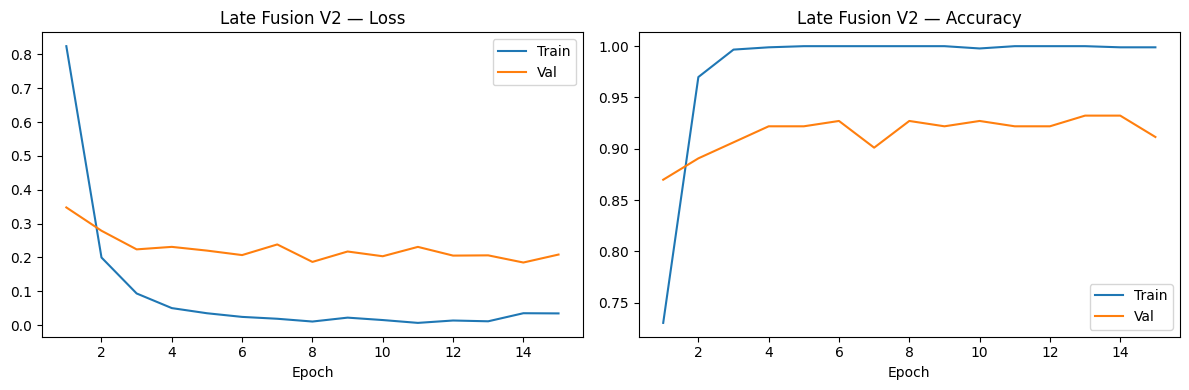

Late Fusion V2 Test Accuracy: 0.9378


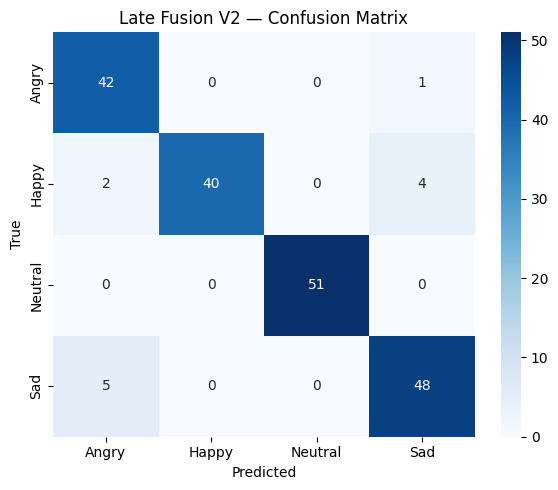

              precision    recall  f1-score   support

       Angry       0.86      0.98      0.91        43
       Happy       1.00      0.87      0.93        46
     Neutral       1.00      1.00      1.00        51
         Sad       0.91      0.91      0.91        53

    accuracy                           0.94       193
   macro avg       0.94      0.94      0.94       193
weighted avg       0.94      0.94      0.94       193



In [25]:
plot_history(lf_v2_history, "Late Fusion V2")
_, lf_v2_acc, lf_v2_preds, lf_v2_labels = eval_epoch(lf_v2, test_loader)
print(f"Late Fusion V2 Test Accuracy: {lf_v2_acc:.4f}")
plot_confusion_matrix(lf_v2_preds, lf_v2_labels, "Late Fusion V2")

## MBT V2 — 학습 안정화

- **LR 1e-4 → 5e-5**: 복잡한 구조에 작은 lr로 안정적 수렴 유도
- **Gradient Clipping (max_norm=1.0)**: loss oscillation 방지
- **Epoch 15 → 20**: 낮은 lr 보상 + 충분한 수렴 시간 확보

In [26]:
def run_training_mbt(model, train_loader, epochs=20, lr=5e-5, weight_decay=1e-4):
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for ids, mask, img, lbl in train_loader:
            ids, mask, img, lbl = ids.to(DEVICE), mask.to(DEVICE), img.to(DEVICE), lbl.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(ids, mask, img), lbl)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            correct    += (model(ids, mask, img).argmax(1) == lbl).sum().item()
            total      += lbl.size(0)
        tr_loss, tr_acc         = total_loss / len(train_loader), correct / total
        val_loss, val_acc, _, _ = eval_epoch(model, val_loader)
        scheduler.step()
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch:2d}/{epochs}  "
              f"Train Loss {tr_loss:.4f}  Acc {tr_acc:.4f}  |  "
              f"Val Loss {val_loss:.4f}  Acc {val_acc:.4f}")
    return history

mbt_v2 = MBTFusionModel(TextEncoder().to(DEVICE), ImageEncoder().to(DEVICE)).to(DEVICE)
print("=== MBT V2 학습 시작 ===")
mbt_v2_history = run_training_mbt(mbt_v2, aug_train_loader)
torch.save(mbt_v2.state_dict(), os.path.join(SAVE_DIR, "mbt_fusion_v2.pt"))
print("가중치 저장 완료: checkpoints/mbt_fusion_v2.pt")

=== MBT V2 학습 시작 ===
Epoch  1/20  Train Loss 0.8016  Acc 0.7681  |  Val Loss 0.3734  Acc 0.8490
Epoch  2/20  Train Loss 0.2345  Acc 0.9799  |  Val Loss 0.5184  Acc 0.8333
Epoch  3/20  Train Loss 0.0797  Acc 0.9978  |  Val Loss 0.5911  Acc 0.8490
Epoch  4/20  Train Loss 0.0365  Acc 1.0000  |  Val Loss 0.3567  Acc 0.9010
Epoch  5/20  Train Loss 0.0198  Acc 0.9989  |  Val Loss 0.3657  Acc 0.8958
Epoch  6/20  Train Loss 0.0237  Acc 1.0000  |  Val Loss 0.2927  Acc 0.9167
Epoch  7/20  Train Loss 0.0386  Acc 1.0000  |  Val Loss 0.3397  Acc 0.9271
Epoch  8/20  Train Loss 0.0159  Acc 0.9989  |  Val Loss 0.4259  Acc 0.9010
Epoch  9/20  Train Loss 0.0093  Acc 1.0000  |  Val Loss 0.3436  Acc 0.9219
Epoch 10/20  Train Loss 0.0259  Acc 1.0000  |  Val Loss 0.4487  Acc 0.8958
Epoch 11/20  Train Loss 0.0049  Acc 1.0000  |  Val Loss 0.3786  Acc 0.9219
Epoch 12/20  Train Loss 0.0050  Acc 1.0000  |  Val Loss 0.5082  Acc 0.8802
Epoch 13/20  Train Loss 0.0268  Acc 1.0000  |  Val Loss 0.3464  Acc 0.9271
Epoc

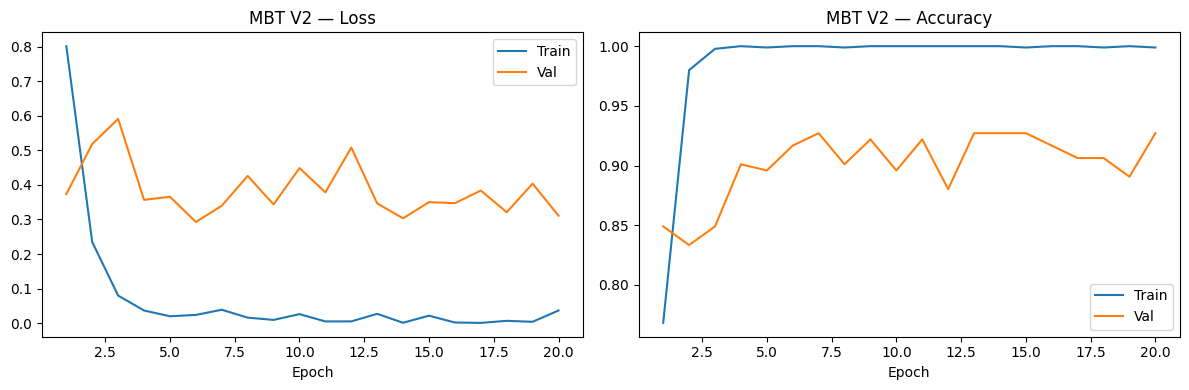

MBT V2 Test Accuracy: 0.9326


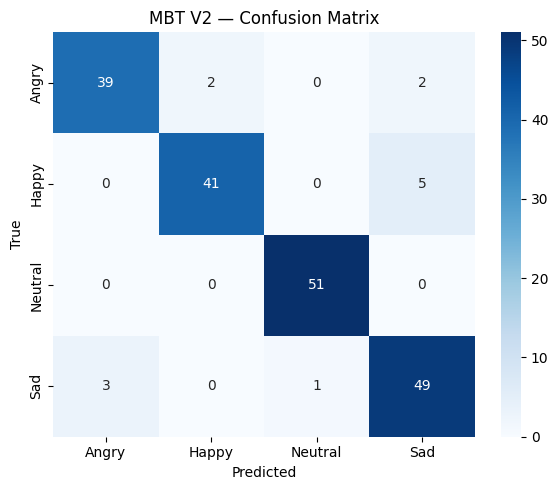

              precision    recall  f1-score   support

       Angry       0.93      0.91      0.92        43
       Happy       0.95      0.89      0.92        46
     Neutral       0.98      1.00      0.99        51
         Sad       0.88      0.92      0.90        53

    accuracy                           0.93       193
   macro avg       0.93      0.93      0.93       193
weighted avg       0.93      0.93      0.93       193



In [27]:
plot_history(mbt_v2_history, "MBT V2")
_, mbt_v2_acc, mbt_v2_preds, mbt_v2_labels = eval_epoch(mbt_v2, test_loader)
print(f"MBT V2 Test Accuracy: {mbt_v2_acc:.4f}")
plot_confusion_matrix(mbt_v2_preds, mbt_v2_labels, "MBT V2")

## 결과 비교 (전략 적용 전/후)

In [28]:
lf_v2_f1  = f1_score(lf_v2_labels,  lf_v2_preds,  average="macro")
mbt_v2_f1 = f1_score(mbt_v2_labels, mbt_v2_preds, average="macro")

print(f"{'모델':<30} {'Test Acc':>10} {'Macro F1':>10}  전략")
print("-" * 75)
print(f"{'Late Fusion (기본)':<30} {lf_test_acc:>10.4f} {lf_f1:>10.4f}  —")
print(f"{'Late Fusion V2':<30} {lf_v2_acc:>10.4f} {lf_v2_f1:>10.4f}  Aug + Dropout↑ + WD↑")
print(f"{'MBT (기본)':<30} {mbt_test_acc:>10.4f} {mbt_f1:>10.4f}  —")
print(f"{'MBT V2':<30} {mbt_v2_acc:>10.4f} {mbt_v2_f1:>10.4f}  Aug + LR↓ + GradClip + Epoch↑")

모델                               Test Acc   Macro F1  전략
---------------------------------------------------------------------------
Late Fusion (기본)                   0.9534     0.9535  —
Late Fusion V2                     0.9378     0.9372  Aug + Dropout↑ + WD↑
MBT (기본)                           0.9275     0.9286  —
MBT V2                             0.9326     0.9321  Aug + LR↓ + GradClip + Epoch↑


### 성능 향상 결과 요약

| 모델 | Test Acc | Macro F1 | 전략 |
|---|---|---|---|
| Late Fusion (기본) | **0.9534** | **0.9535** | — |
| Late Fusion V2 | 0.9378 | 0.9372 | Aug + Dropout↑ + WD↑ |
| MBT (기본) | 0.9275 | 0.9286 | — |
| MBT V2 | 0.9326 | 0.9321 | Aug + LR↓ + GradClip + Epoch↑ |

**분석:**
- Late Fusion V2 성능 하락 → Dropout 0.5 + WD 1e-3이 과도한 regularization으로 작용
- MBT V2 소폭 개선 → LR↓ + Gradient Clipping이 학습 안정화에 효과적
- 최종 우수 모델: **Late Fusion 기본 (Test Acc 0.9534)**

# 7. 결과

## 우수 모델

**Late Fusion (기본)** — Test Acc 0.9534 / Macro F1 0.9535

### 이유

1. **데이터 규모 적합성**: 1,282개의 소규모 데이터셋에서 Late Fusion의 단순한 구조가 유리
   - MBT의 병목 트랜스포머 레이어는 충분한 데이터 없이는 과적합에 취약

2. **모달리티 독립성**: 텍스트(AraBERT)와 이미지(ResNet50)가 각자 독립적으로 학습 후 결합
   - 모로코 아랍어 텍스트는 AraBERT가, 스펙트로그램은 ResNet50이 각각 특화된 특징 추출

3. **학습 안정성**: Loss가 일관되게 감소, MBT 대비 oscillation 없음

## 분석 및 결론

### 전체 실험 요약

| 항목 | 내용 |
|---|---|
| 데이터 | MDER-MA (모로코 아랍어), 1,282개, 4감정 |
| 텍스트 encoder | AraBERT (aubmindlab/bert-base-arabertv02), max_length=64 |
| 이미지 encoder | ResNet50, Mel-Spectrogram 224×224 |
| Fusion 방식 | Late Fusion vs MBT Bottleneck Fusion |
| 최고 성능 | Late Fusion — Test Acc 0.9534, Macro F1 0.9535 |

### 결론

- **가설 검증 실패**: MBT가 Late Fusion보다 우수할 것이라는 가설은 기각
  - 소규모 데이터에서는 단순한 fusion 방식이 더 효과적임을 확인
- **공통 과제**: 두 모델 모두 Epoch 3~5에서 Train Acc 1.0 도달 → 과적합
  - 더 많은 데이터 수집 또는 stronger augmentation이 근본적 해결책
- **클래스별 성능**: Neutral 클래스 일관되게 가장 높음, Angry/Sad는 상대적으로 낮음
  - Angry: 샘플 수 가장 적음(291개), weighted loss로 일부 보완
- **MBT 가능성**: 더 많은 데이터(수만 건 이상)와 lower LR 환경에서는 MBT가 우위를 보일 가능성 있음